### Entrega semana 13 (Yolo). 
Alejandro Alemán Alemán  
Manuel Alejandro Torrealba  
Álvaro Serrano Delmás

### Ejercicio 2:  
#### Usa la posición detectada en el Frame 1 como punto inicial y realiza el seguimiento del punto con el método Lucas–Kanade.


En este segundo ejercicio hacemos uso de YOLO pose y Lucas Kanade para poder detectar la mano derecha de una persona y ahcer un seguimiento de ella en todo el vídeo.

In [39]:
from ultralytics import YOLO
import cv2 as cv
import matplotlib.pyplot as plt

model = YOLO("yolov8n-pose.pt")

video_path = "videos/people2.mp4"  
cap = cv.VideoCapture(video_path)

ret, frame1 = cap.read()

results = model(frame1)[0]

annotated = results.plot()


0: 384x640 6 persons, 124.6ms
Speed: 5.8ms preprocess, 124.6ms inference, 11.1ms postprocess per image at shape (1, 3, 384, 640)


En este primer bloque hacemos uso del modelo YOLO pose, cargamos el primer frame del vídeo "people2", y obtenemos las detecciones del primer frame de dicho vídeo.

In [40]:
kps = results.keypoints.data.cpu().numpy()

# Elegimos la persona 0 
kp = kps[0]

# Mano derecha (índice 10)
x0, y0, conf = kp[10]

print(f"Mano derecha de la persona 0: ({x0:.1f}, {y0:.1f})")


Mano derecha de la persona 0: (816.8, 697.5)


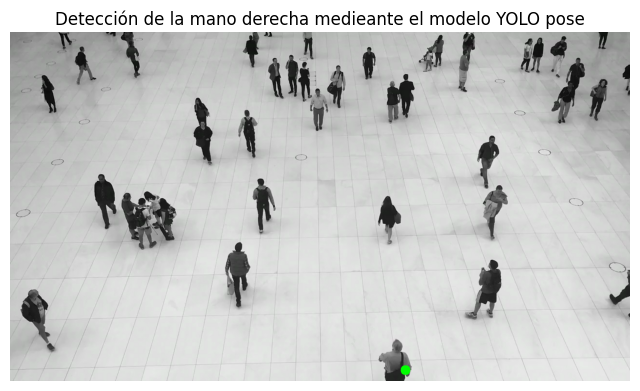

In [41]:
img_plot = frame1.copy()
cv.circle(img_plot, (int(x0), int(y0)), 10, (0,255,0), -1)   

plt.figure(figsize=(8,8))
plt.imshow(img_plot)
plt.title("Detección de la mano derecha medieante el modelo YOLO pose")
plt.axis("off")
plt.show()

Una vez visto que la detección del primer frame ha sido satisfactoria continuamos con el algorítmo Lucas Kanade para poder hacer un seguimiento de la mano durante todo el vídeo. Para implementar este algorimo se utilizó Chat Gpt.

In [42]:
lk_params = dict(
    winSize=(21, 21),
    maxLevel=3,
    criteria=(cv.TERM_CRITERIA_EPS | cv.TERM_CRITERIA_COUNT, 30, 0.01)
)

p0 = np.array([[x0, y0]], dtype=np.float32).reshape(-1, 1, 2)

gray1 = cv.cvtColor(frame1, cv.COLOR_BGR2GRAY)

xs = [x0]
ys = [y0]
frames_output = []

while True:
    ret, frame2 = cap.read()
    if not ret:
        break

    gray2 = cv.cvtColor(frame2, cv.COLOR_BGR2GRAY)

    p1, st, err = cv.calcOpticalFlowPyrLK(gray1, gray2, p0, None, **lk_params)

    if st[0][0] == 1:  
        x1, y1 = p1[0][0]

        xs.append(x1)
        ys.append(y1)

        cv.circle(frame2, (int(x1), int(y1)), 7, (0,255,0), -1)

    frames_output.append(frame2.copy())

    gray1 = gray2.copy()
    p0 = p1.reshape(-1, 1, 2)

cap.release()
cv.destroyAllWindows()
cv.waitKey(1)

-1

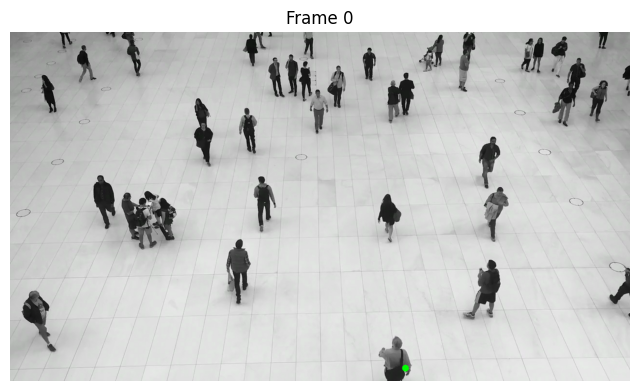

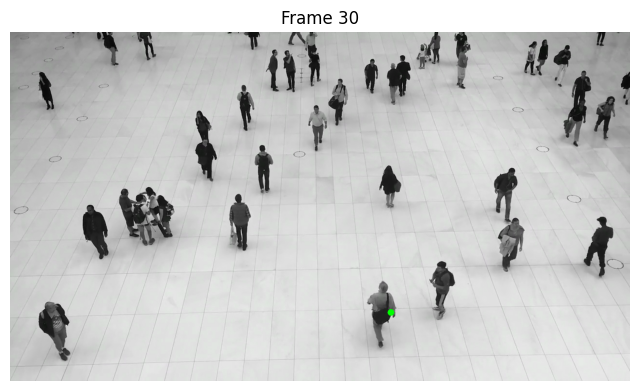

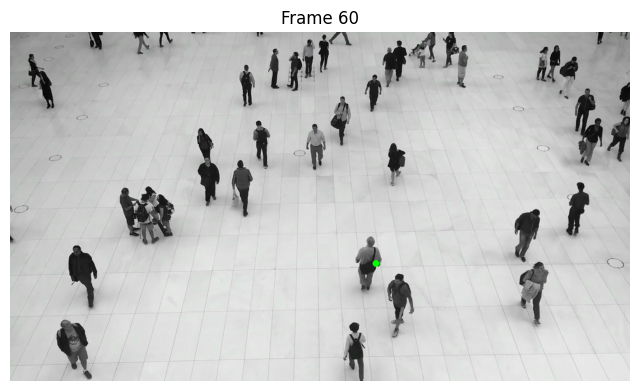

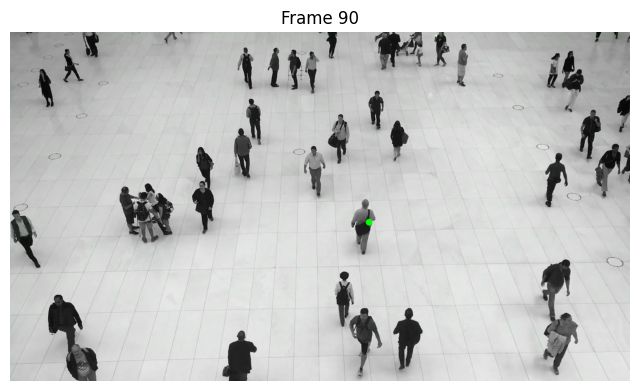

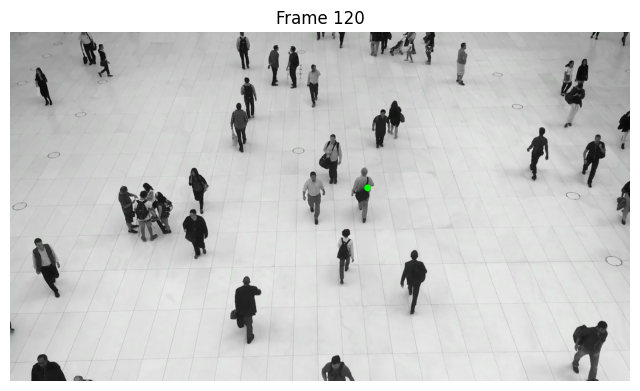

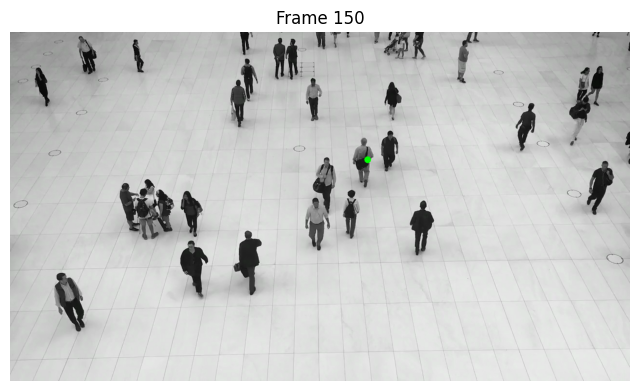

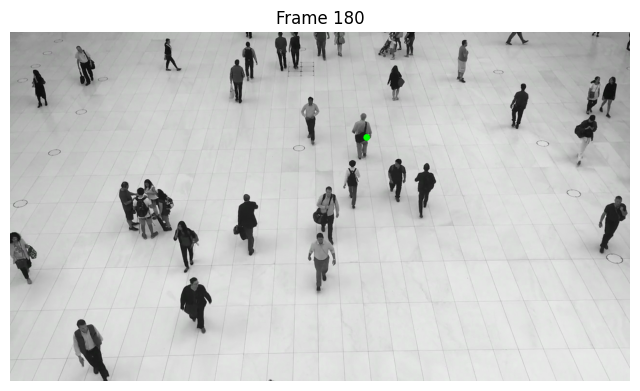

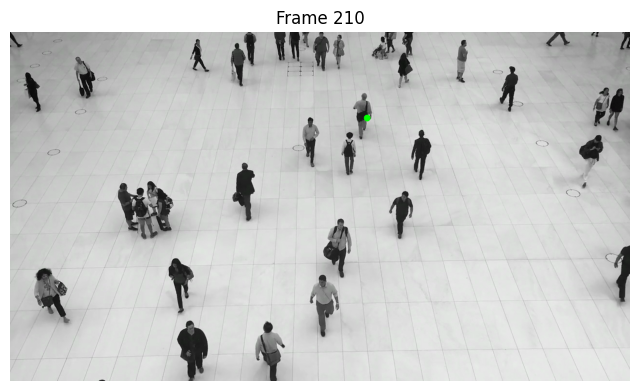

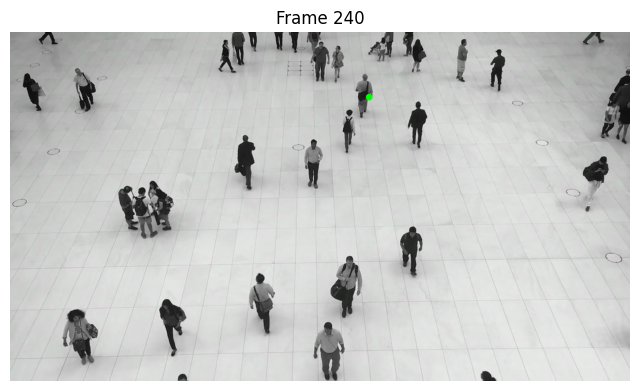

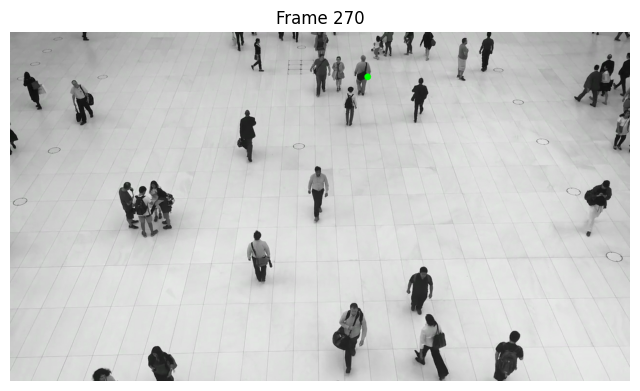

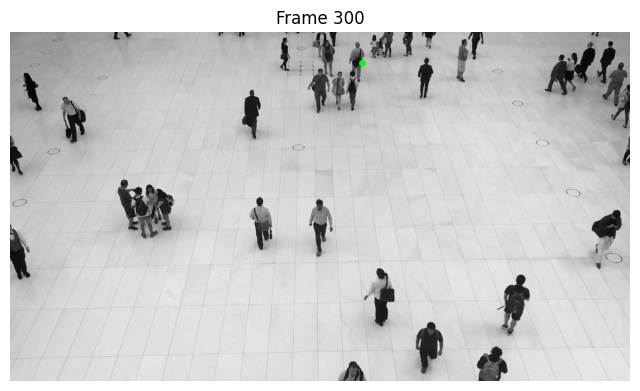

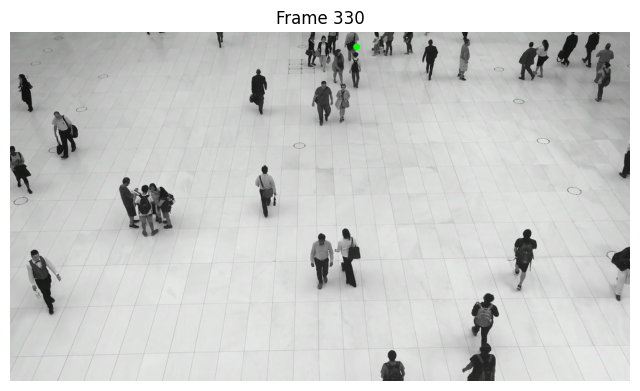

In [43]:
for i in range(0, len(frames_output), 30):  
    plt.figure(figsize=(8,6))
    plt.imshow(cv.cvtColor(frames_output[i], cv.COLOR_BGR2RGB))
    plt.title(f"Frame {i}")
    plt.axis("off")
    plt.show()


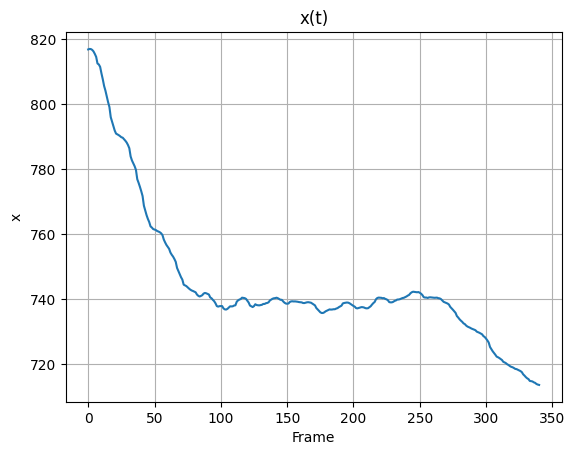

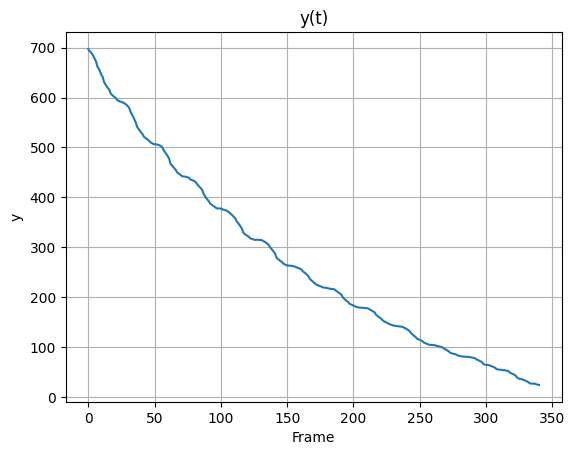

In [44]:
plt.plot(xs)
plt.title("x(t)")
plt.xlabel("Frame")
plt.ylabel("x")
plt.grid()
plt.show()

plt.plot(ys)
plt.title("y(t)")
plt.xlabel("Frame")
plt.ylabel("y")
plt.grid()
plt.show()


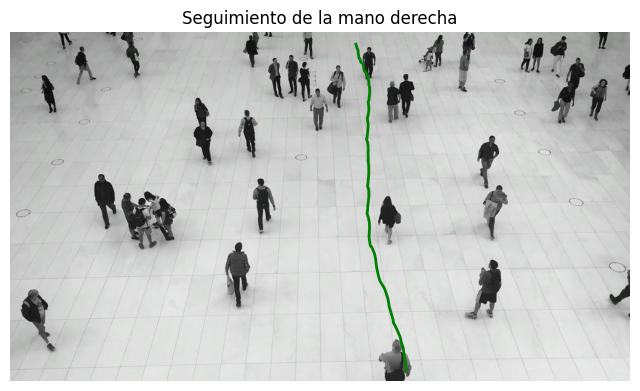

In [45]:
plt.figure(figsize=(8,6))
plt.imshow(cv.cvtColor(frame1, cv.COLOR_BGR2RGB))
plt.plot(xs, ys, 'g-', linewidth=2)
plt.title(f"Seguimiento de la mano derecha")
plt.axis("off")
plt.show()